# Operaciones puntuales y transformaciones sobre imágenes

Grupo:
- 190242 Thiago Puyelli
- 174264 Matias Herrneder
- 190306 Valentín J. Romero Monteagudo

**Proyecto trabajo práctico:** software de detección de manipulación de imágenes.

Este notebook implementa las operaciones puntuales exigidas en el TP2 (negativo,
umbral simple, umbral binario, umbral en escala de grises, extensión de niveles de
gris, reducción de niveles de gris, rodaja de planos de bits), las transformaciones
adición y sustracción, y un **operador propio** (realce de banda de interés).

### Imágenes de trabajo

El proyecto trabaja con imágenes en color que se convierten a **escala de grises**:

- `img/Gemini_Generated_Image.jpeg` — imagen generada sintéticamente (IA), imagen
  principal sobre la que se demuestran las operaciones.
- `img/patente_original.jpg` — fotografía original de una patente (captura de
  referencia), segunda imagen para las transformaciones.

Al estar en color (RGB), la carga las convierte a grises de 8 bits (requisito del
enunciado). Como tienen tamaños distintos, la segunda se **redimensiona** al tamaño
de la primera para poder sumarla/restarla.

## 1. Preparación

Importamos las librerías, cargamos las imágenes en grises y definimos un helper de
visualización que normaliza el rango mostrado al mínimo/máximo real de cada imagen.

In [49]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

RUTA_1 = "img/Gemini_Generated_Image.jpeg"
RUTA_2 = "img/patente_original.jpg"


def cargar(ruta, tamano=None):
    """Carga una imagen en escala de grises de 8 bits (uint8).

    Si viene en color la convierte a grises. Si `tamano` se indica, la
    redimensiona a ese tamaño (necesario para adición/sustracción).
    """
    imagen = Image.open(ruta)
    if imagen.mode != "L":
        imagen = imagen.convert("L")
    if tamano is not None and imagen.size != tamano:
        imagen = imagen.resize(tamano, Image.LANCZOS)
    return np.asarray(imagen).astype(np.uint8)


imagen_1 = cargar(RUTA_1)
imagen_2 = cargar(RUTA_2, tamano=imagen_1.shape[::-1])

print(f"Imagen 1: {imagen_1.shape} | dtype: {imagen_1.dtype} | rango: {imagen_1.min()}-{imagen_1.max()}")
print(f"Imagen 2: {imagen_2.shape} | dtype: {imagen_2.dtype} | rango: {imagen_2.min()}-{imagen_2.max()}"
      f" (redimensionada a {imagen_1.shape[1]}x{imagen_1.shape[0]})")

Imagen 1: (843, 1264) | dtype: uint8 | rango: 0-255
Imagen 2: (843, 1264) | dtype: uint8 | rango: 0-255 (redimensionada a 1264x843)


In [50]:
def niveles(dtype):
    """Número total de niveles de gris L según el dtype (256 para uint8)."""
    return int(2 ** np.iinfo(dtype).bits)


def mostrar(imagenes, titulos=None, figsize=None, cmap="gray", normalizar=True):
    """Muestra una lista de imágenes en una fila.

    Normaliza `vmin`/`vmax` al mínimo/máximo real de cada imagen para que
    cualquier profundidad se visualice correctamente.
    """
    if not isinstance(imagenes, (list, tuple)):
        imagenes = [imagenes]
    n = len(imagenes)
    figsize = figsize or (4 * n, 4)
    _, ejes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        ejes = [ejes]
    for i, img in enumerate(imagenes):
        arr = np.asarray(img)
        vmin, vmax = None, None
        if normalizar:
            vmin = float(np.nanmin(arr))
            vmax = float(np.nanmax(arr))
            if vmin == vmax:
                vmax = vmin + 1.0
        ejes[i].imshow(arr, cmap=cmap if arr.ndim == 2 else None, vmin=vmin, vmax=vmax)
        ejes[i].axis("off")
        if titulos and i < len(titulos):
            ejes[i].set_title(titulos[i])
    plt.tight_layout()
    plt.show()

## 2. Operaciones puntuales

Transforman cada píxel de forma independiente: $s = T(r)$. Se definen en escala de
grises; para imágenes en color se aplican a cada canal por separado (sección 2.9).

De aquí en adelante, **todos los resultados se muestran sobre la imagen generada por
IA (imagen 1)**, salvo que se indique lo contrario.

### 2.1 Identidad

$s = r$. Devuelve la imagen tal cual; sirve como referencia para comparar.

- **Datos que se obtienen**: réplica exacta de la imagen (los valores de gris no
  cambian).
- **Utilidad en el proyecto**: línea base de control para validar que el resto de los
  operadores transforman correctamente; en el flujo forense se usa como referencia de
  las condiciones originales de captura.

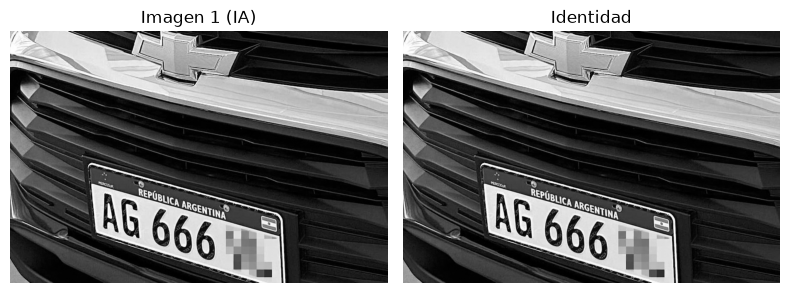

In [51]:
def identidad(arr):
    """Identidad: s = r. Devuelve la imagen sin cambios."""
    return np.array(arr)


mostrar([imagen_1, identidad(imagen_1)], titulos=["Imagen 1 (IA)", "Identidad"])

### 2.2 Inverso o negativo

$s = L - 1 - r$, con $L = 256$ niveles. Invierte los tonos.

- **Datos que se obtienen**: imagen con distribución complementaria de grises; el
  fondo claro pasa a oscuro y el objeto oscuro a claro.
- **Utilidad en el proyecto**: permite inspeccionar zonas saturadas o muy claras
  (donde el detalle se perdía) y se usa como paso previo para trabajar máscaras
  binarias complementarias.

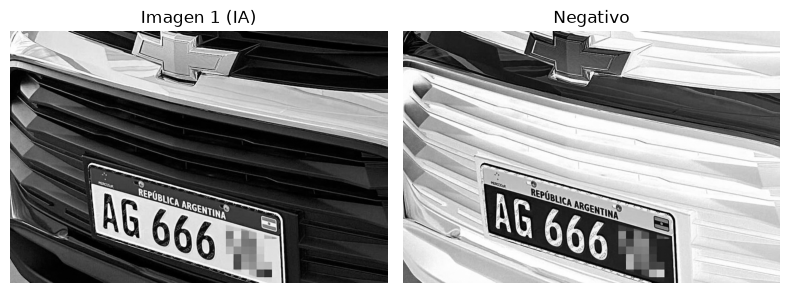

In [52]:
def negativo(arr):
    """Inverso: s = L - 1 - r."""
    maximo = niveles(arr.dtype) - 1
    return (maximo - arr.astype(np.int32)).astype(arr.dtype)


mostrar([imagen_1, negativo(imagen_1)], titulos=["Imagen 1 (IA)", "Negativo"])

### 2.3 Umbral simple

$s = 0$ si $r < T$ y $s = 255$ en caso contrario. Produce una imagen binaria.

- **Datos que se obtienen**: máscara binaria que separa la escena en dos clases
  según la intensidad (fondo/objeto).
- **Utilidad en el proyecto**: segmentar regiones candidatas (por ejemplo aislar
  elementos muy claros u oscuros) antes de un análisis forense localizado.

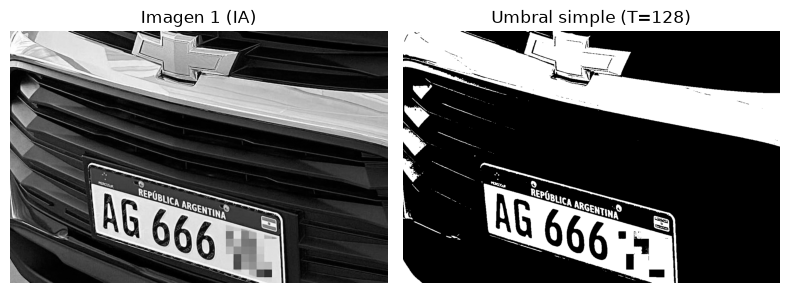

In [53]:
def umbral(arr, t):
    """Umbral binario simple: 0 si r < t, 255 en caso contrario."""
    maximo = niveles(arr.dtype) - 1
    return np.where(arr < t, 0, maximo).astype(arr.dtype)


T = 128
mostrar([imagen_1, umbral(imagen_1, T)],
        titulos=["Imagen 1 (IA)", f"Umbral simple (T={T})"])

### 2.4 Intervalo umbral binario

$s = 255$ si $a \leq r \leq b$ y $s = 0$ si no. Resalta solo la banda delimitada.

- **Datos que se obtienen**: máscara binaria de la región cuya intensidad cae en el
  intervalo $[a, b]$.
- **Utilidad en el proyecto**: localizar píxeles con intensidades típicas de un objeto
  específico (aquí, el elemento iluminado sobre un fondo oscuro), base para detectar
  elementos duplicados o insertados en copy-move/splicing.

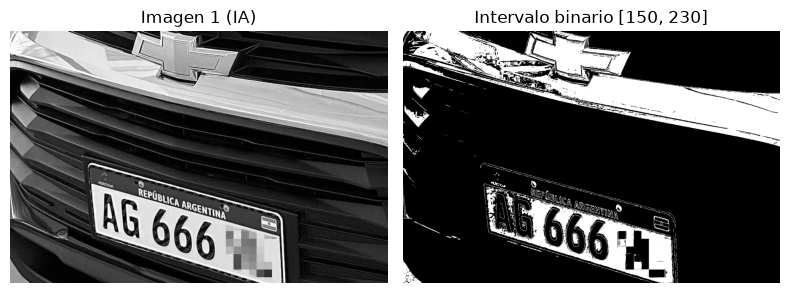

In [54]:
def umbral_intervalo_binario(arr, a, b):
    """Intervalo umbral binario: 255 si a <= r <= b, 0 en el resto."""
    maximo = niveles(arr.dtype) - 1
    return np.where((arr >= a) & (arr <= b), maximo, 0).astype(arr.dtype)


a_banda, b_banda = 150, 230
mostrar([imagen_1, umbral_intervalo_binario(imagen_1, a_banda, b_banda)],
        titulos=["Imagen 1 (IA)", f"Intervalo binario [{a_banda}, {b_banda}]"])

### 2.5 Umbral en escala de grises

Variante del intervalo: dentro de $[a, b]$ se **conserva el valor original** de gris
y fuera se pone $0$.

- **Datos que se obtienen**: la banda de interés conserva su contenido interno;
  el resto queda negro.
- **Utilidad en el proyecto**: inspeccionar el detalle interno de una región sin la
  distracción del fondo; permite ver la textura de una zona sospechosa (por ejemplo
  el elemento iluminado de la imagen generada) manteniendo su información de intensidad.

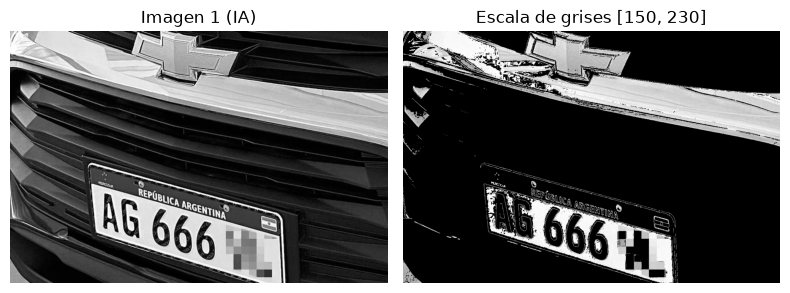

In [55]:
def umbral_escala_grises(arr, a, b):
    """Conserva los grises dentro de [a, b] y pone 0 fuera del intervalo."""
    return np.where((arr >= a) & (arr <= b), arr, 0).astype(arr.dtype)


mostrar([imagen_1, umbral_escala_grises(imagen_1, a_banda, b_banda)],
        titulos=["Imagen 1 (IA)", f"Escala de grises [{a_banda}, {b_banda}]"])

### 2.6 Extensión de niveles de gris

Estiramiento lineal de contraste: mapea $[r_{min}, r_{max}]$ al rango completo
$[0, 255]$.

- **Datos que se obtienen**: imagen con el rango dinámico completo, con mayor
  separación entre tonos (más contraste).
- **Utilidad en el proyecto**: revelar cambios sutiles de iluminación o gradientes
  locales que en la versión original pasan desapercibidos; un ajuste de brillo/contraste
  hecho por un editor deja huellas que esta operación ayuda a visualizar.

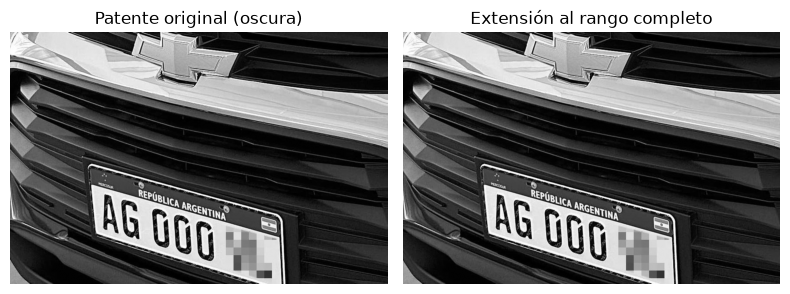

In [56]:
def extension_niveles_gris(arr, minimo=None, maximo=None):
    """Extensión lineal [minimo, maximo] -> [0, L-1]."""
    maximo_out = niveles(arr.dtype) - 1
    rmin = arr.min() if minimo is None else minimo
    rmax = arr.max() if maximo is None else maximo
    if rmax <= rmin:
        return np.array(arr)
    escala = maximo_out / (rmax - rmin)
    estirada = (arr.astype(np.float64) - rmin) * escala
    return np.clip(estirada, 0, maximo_out).astype(arr.dtype)


mostrar([imagen_2, extension_niveles_gris(imagen_2)],
        titulos=["Patente original (oscura)", "Extensión al rango completo"])

### 2.7 Reducción de niveles de gris

Cuantiza los valores a $2^{bits}$ niveles y los **re-expande** al rango completo
(posterización: aparecen bandas de tono pero no se oscurece).

- **Datos que se obtienen**: imagen con $2^{bits}$ niveles de gris (bandas visibles
  en degradados).
- **Utilidad en el proyecto**: cuantificar la pérdida de calidad por guardado,
  reescalado o re-compresión; los re-encodes agresivos dejan bandas de tono que esta
  operación expone claramente.

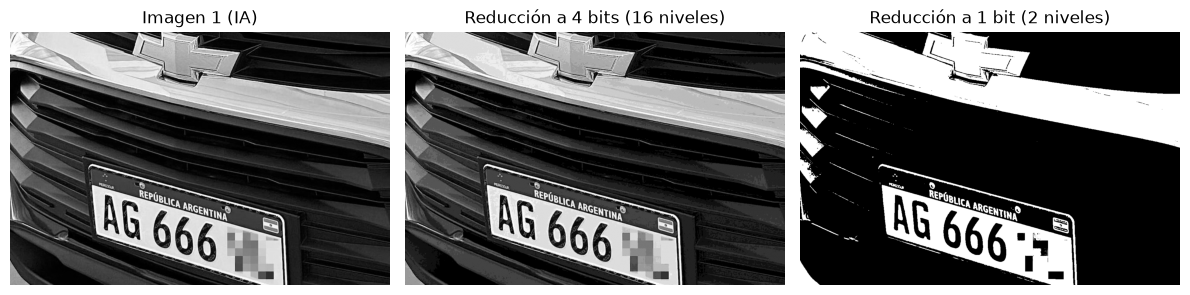

In [57]:
def reduccion_niveles_gris(arr, bits):
    """Cuantiza a 2^bits niveles y re-expande al rango completo [0, L-1]."""
    maximo = niveles(arr.dtype) - 1
    if bits >= int(np.log2(niveles(arr.dtype))):
        return np.array(arr)
    cuantos = (1 << bits) - 1
    arr_f = arr.astype(np.float64) / maximo
    cuantizada = np.round(arr_f * cuantos) / cuantos
    return (cuantizada * maximo).astype(arr.dtype)


mostrar([imagen_1,
         reduccion_niveles_gris(imagen_1, 4),
         reduccion_niveles_gris(imagen_1, 1)],
        titulos=["Imagen 1 (IA)",
                 "Reducción a 4 bits (16 niveles)",
                 "Reducción a 1 bit (2 niveles)"])

### 2.8 Rodaja de planos de bits

Una imagen de 8 bits se descompone en **8 planos binarios**, uno por bit
($0$ = menos significativo, $7$ = más significativo). El plano $p$ vale 255 donde el
$p$-ésimo bit está encendido y 0 donde no.

- **Datos que se obtienen**: 8 imágenes binarias; los planos altos concentran la
  información visual gruesa y los bajos el ruido/fines.
- **Utilidad en el proyecto (clave forense)**: una manipulación local (splicing o
  copy-move) suele dejar su firma en los planos de bits: estadísticas de ruido
  diferentes, bordes de composición visibles en planos altos, o regiones con
  transiciones "demasiado limpias" propias de re-muestreo digital.

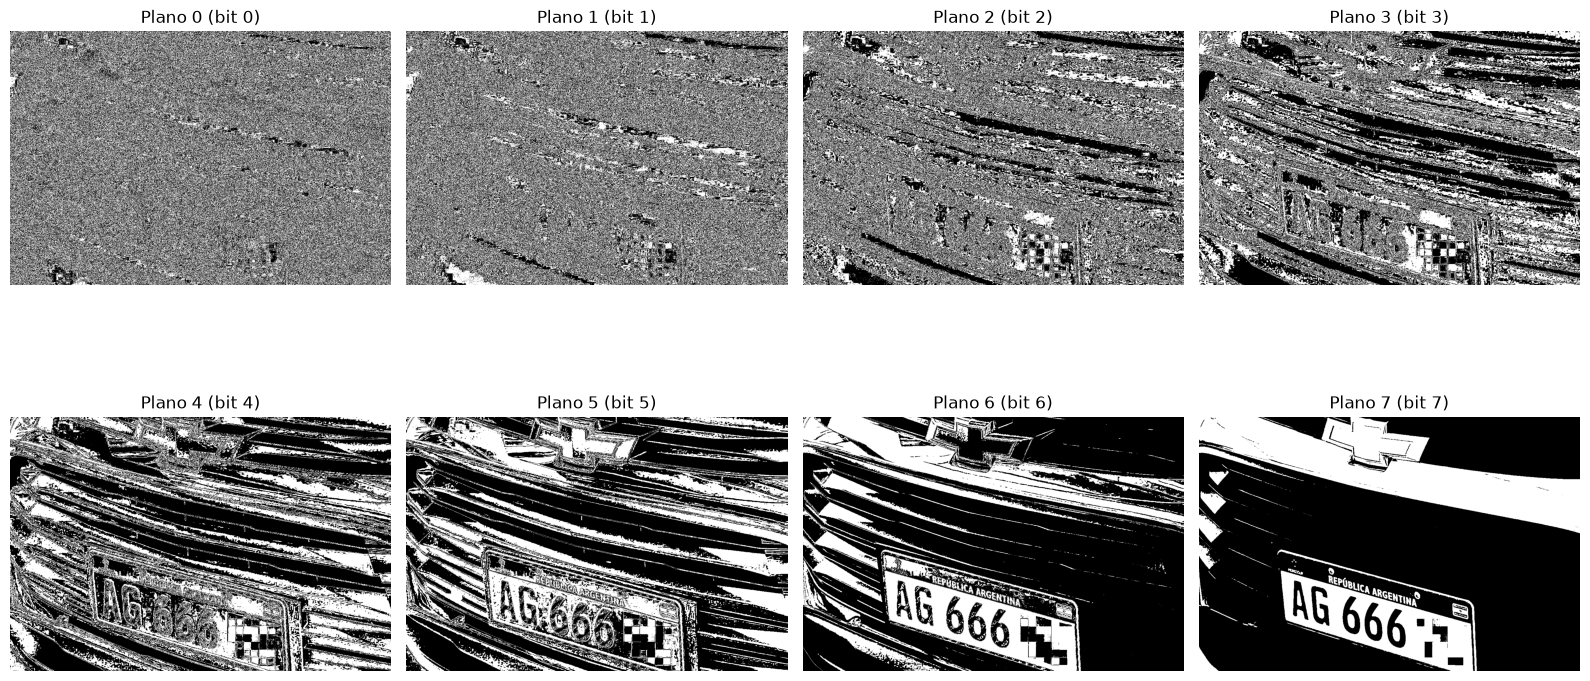

In [58]:
def plano_de_bits(arr, p):
    """Extrae como binario (0/255) el plano de bit p (0 = menos significativo)."""
    return (((arr >> p) & 1) * 255).astype(np.uint8)


fig, ejes = plt.subplots(2, 4, figsize=(16, 9))
for p in range(8):
    ejes[p // 4, p % 4].imshow(plano_de_bits(imagen_1, p), cmap="gray", vmin=0, vmax=255)
    ejes[p // 4, p % 4].set_title(f"Plano {p} (bit {p})")
    ejes[p // 4, p % 4].axis("off")
plt.tight_layout()
plt.show()

Reconstrucción correcta: True


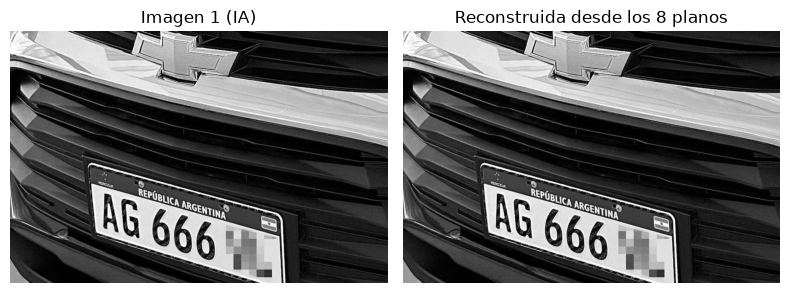

In [59]:
def reconstruir(planos):
    """Reconstruye la imagen original sumando los planos ponderados: plano p -> 2^p."""
    return sum((plano.astype(np.uint16) // 255) << p
               for p, plano in enumerate(planos)).astype(np.uint8)


planos = [plano_de_bits(imagen_1, p) for p in range(8)]
reconstruida = reconstruir(planos)

print("Reconstrucción correcta:", np.array_equal(reconstruida, imagen_1))
mostrar([imagen_1, reconstruida],
        titulos=["Imagen 1 (IA)", "Reconstruida desde los 8 planos"])

## 3. Operador propio: realce de banda de interés

**Diseño.** Se construye componiendo dos operadores puntuales ya desarrollados:
el **umbral en escala de grises** (2.5) y la **extensión de niveles de gris** (2.6).

- Dentro de la banda $[a, b]$ se estira el contraste linealmente al rango completo.
- Fuera de la banda, los píxeles se llevan a un **fondo** (0 por defecto).

La banda $[a, b]$ se elige a partir del **histograma** de la imagen. La imagen
generada por IA es muy oscura (moda ≈ 2) y su contenido iluminado ocupa los niveles
altos (percentil 75 ≈ 160, 90 ≈ 222), por lo que $[150, 230]$ aísla ese elemento con
su detalle interno.

Es 100 % puntual: cada píxel depende solo de su valor $r$ y de los parámetros fijos
$a$, $b$ y el fondo; no se usan estadísticas globales dentro de la función.

**Datos que se obtienen**: la banda de interés queda **estirada al rango completo**
$[0, 255]$, multiplicando su contraste interno (los tonos bajos de la banda se
oscurecen y los altos se aclaran), mientras el resto queda en negro.

**Utilidad en el proyecto**: es una herramienta de *primer análisis forense*: aísla la
banda de intensidad típica de un elemento (en este caso el objeto iluminado de la
imagen generada) y **amplifica su detalle interno**, facilitando ver el granulado, el
ruido de sensor o los bordes de composición que evidencian una manipulación local.

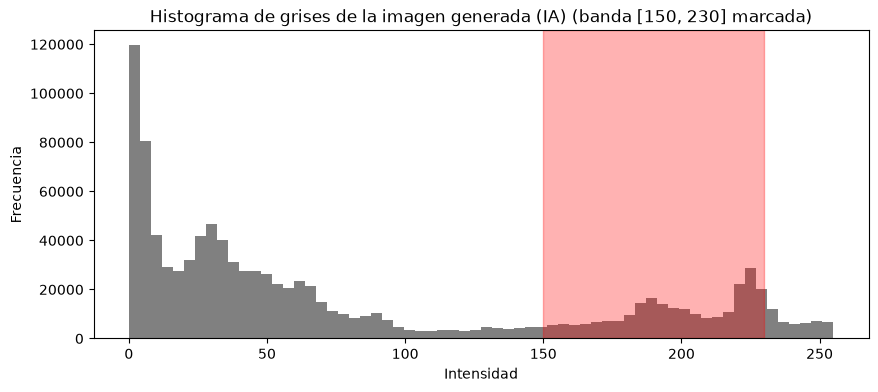

In [61]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(imagen_1.ravel(), bins=64, range=(0, 255), color="gray")
ax.axvspan(a_banda, b_banda, color="red", alpha=0.3)
ax.set_title("Histograma de grises de la imagen generada (IA) (banda [150, 230] marcada)")
ax.set_xlabel("Intensidad")
ax.set_ylabel("Frecuencia")
plt.show()

Píxeles en banda [150,230]: 21.7%
Umbral en grises | media en banda: 199.3 | max: 230
Realce (propio)  | media en banda: 157.5 | max: 255


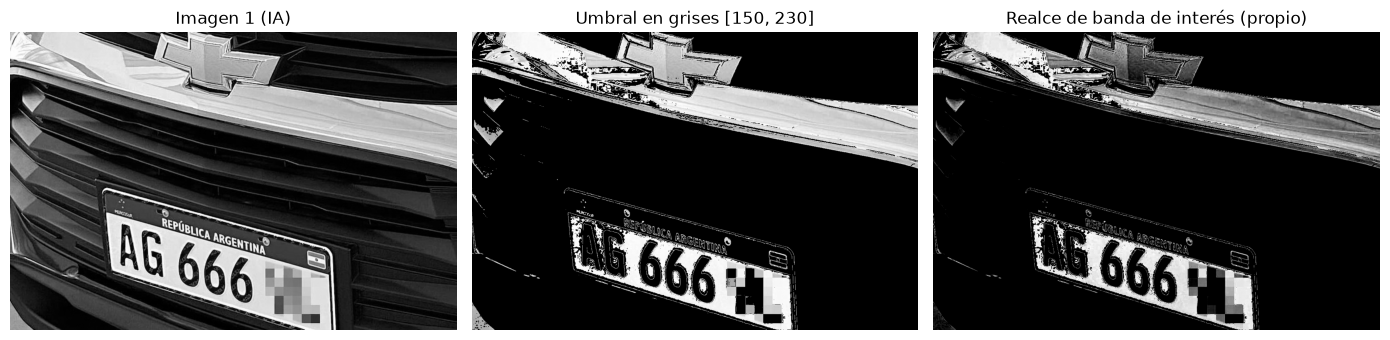

In [62]:
def realce_banda_interes(arr, a, b, fondo=0):
    """Operador propio: estira el contraste dentro de [a, b] al rango completo
    [0, L-1] y apaga el resto de niveles (fondo)."""
    maximo = niveles(arr.dtype) - 1
    rango = b - a
    if rango <= 0:
        return np.array(arr)
    banda = np.clip((arr.astype(np.float64) - a) * (maximo / rango), 0, maximo).astype(arr.dtype)
    mascara = (arr >= a) & (arr <= b)
    return np.where(mascara, banda, fondo).astype(arr.dtype)


base = umbral_escala_grises(imagen_1, a_banda, b_banda)
propio = realce_banda_interes(imagen_1, a_banda, b_banda)
mascara = (imagen_1 >= a_banda) & (imagen_1 <= b_banda)
print(f"Píxeles en banda [{a_banda},{b_banda}]: {100*mascara.mean():.1f}%")
print(f"Umbral en grises | media en banda: {base[base > 0].mean():.1f} | max: {base.max()}")
print(f"Realce (propio)  | media en banda: {propio[propio > 0].mean():.1f} | max: {propio.max()}")
mostrar([imagen_1, base, propio],
        titulos=["Imagen 1 (IA)",
                 f"Umbral en grises [{a_banda}, {b_banda}]",
                 "Realce de banda de interés (propio)"],
        figsize=(14, 5), normalizar=False)

## 4. Transformaciones entre imágenes

Combinan **dos imágenes** píxel a píxel; exigen el mismo tamaño. La imagen 2 ya fue
redimensionada en la preparación.

### 4.1 Adición

$s = r_1 + r_2$, recortada al rango válido $[0, 255]$.

- **Datos que se obtienen**: composición de las dos imágenes punto a punto.
- **Utilidad en el proyecto**: componer escenas y sumar ruido controlado; en el
  análisis de secuencias, **promediar** varias capturas reduce el ruido y mejora la
  relación señal/ruido antes de detectar manipulaciones.

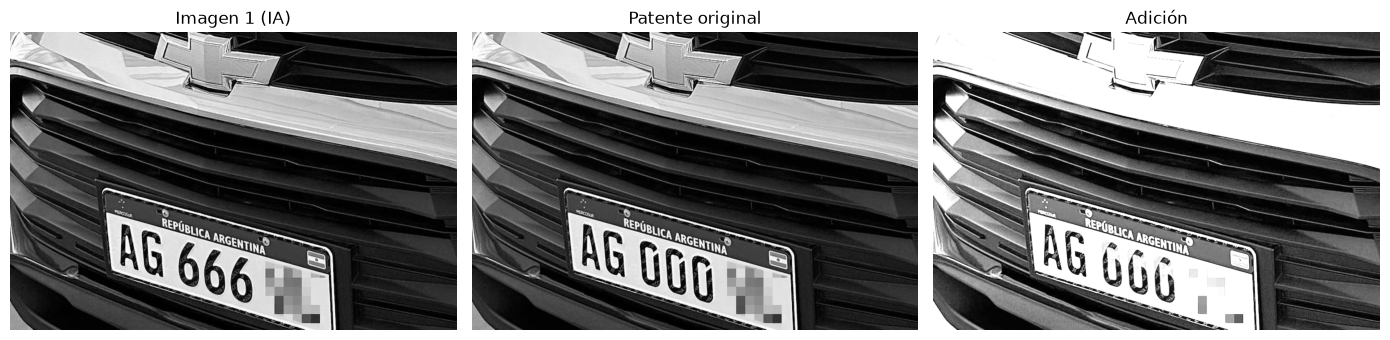

In [63]:
def adicion(a, b):
    """Suma de dos imágenes del mismo tamaño, recortada al rango válido."""
    maximo = niveles(a.dtype) - 1
    suma = a.astype(np.int32) + b.astype(np.int32)
    return np.clip(suma, 0, maximo).astype(a.dtype)


mostrar([imagen_1, imagen_2, adicion(imagen_1, imagen_2)],
        titulos=["Imagen 1 (IA)", "Patente original", "Adición"],
        figsize=(14, 5))

### 4.2 Sustracción

$s = |r_1 - r_2|$. Resalta las **diferencias**.

- **Datos que se obtienen**: imagen donde los píxeles idénticos valen 0 (negro) y las
  zonas distintas se iluminan según la magnitud del cambio.
- **Utilidad en el proyecto (núcleo de la detección)**: comparar una imagen contra su
  versión editada muestra **exactamente la región modificada**. Es el primer paso del
  flujo forense: si la resta es no nula en una zona, esa zona fue alterada.

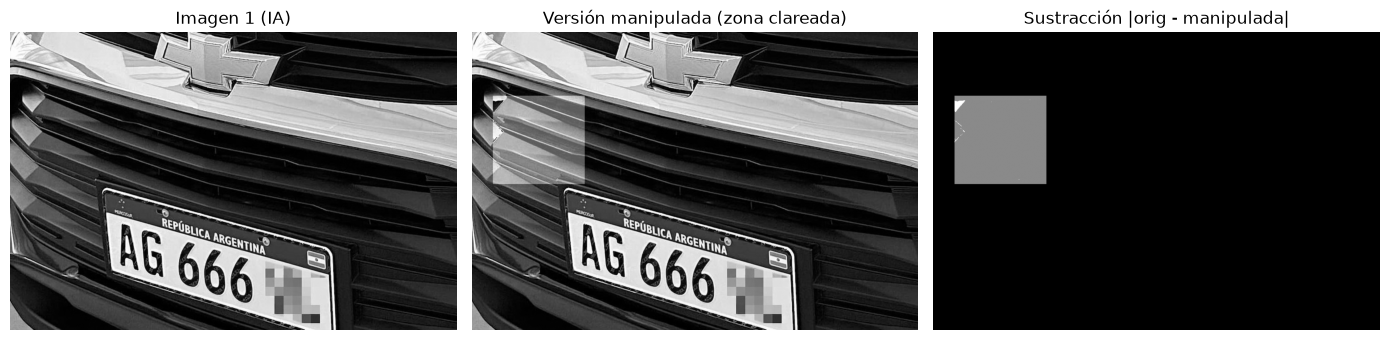

In [64]:
def sustraccion(a, b):
    """Valor absoluto de la diferencia de dos imágenes del mismo tamaño."""
    return np.abs(a.astype(np.int32) - b.astype(np.int32)).astype(a.dtype)


# Simulación de manipulación: se clarea una región de la imagen (edición local)
tocada = np.array(imagen_1)
tocada[180:430, 60:320] = np.clip(tocada[180:430, 60:320] + 90, 0, 255)

mostrar([imagen_1, tocada, sustraccion(imagen_1, tocada)],
        titulos=["Imagen 1 (IA)", "Versión manipulada (zona clareada)",
                 "Sustracción |orig - manipulada|"],
        figsize=(14, 5))

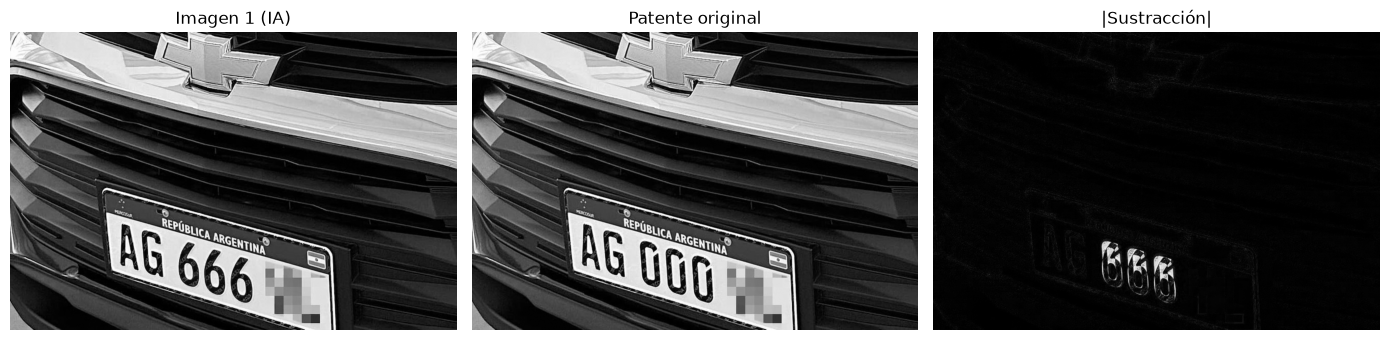

In [65]:
# Comparación general entre las dos imágenes del proyecto
mostrar([imagen_1, imagen_2, sustraccion(imagen_1, imagen_2)],
        titulos=["Imagen 1 (IA)", "Patente original", "|Sustracción|"],
        figsize=(14, 5))

## 5. Resumen: qué información aporta cada operador

| Operador | Datos que se obtienen | Utilidad en detección de manipulación |
|---|---|---|
| Identidad | Referencia sin cambios | Comparación / control |
| Negativo | Distribución de grises invertida | Revisar zonas saturadas, máscaras complementarias |
| Umbral simple | Máscara binaria (2 clases) | Segmentar regiones candidatas |
| Intervalo umbral binario | Máscara de la banda [a, b] | Aislar elementos de intensidad característica |
| Umbral en escala de grises | Banda conservando detalle interno | Inspeccionar textura interna de una región |
| Extensión | Contraste estirado al rango completo | Visualizar cambios sutiles de iluminación/edición |
| Reducción de niveles | Posterización a 2^bits niveles | Exponer re-encodes y pérdidas de calidad |
| Rodaja de planos de bits | 8 planos binarios | Firmas de edición (ruido, bordes, re-muestreo) |
| Adición | Composición de dos imágenes | Composición; promediado para reducir ruido |
| Sustracción | Diferencia absoluta punto a punto | Señalar la región alterada |
| **Realce de banda (propio)** | Banda estirada, resto a fondo | Amplificar el detalle de un elemento sospechoso |
